# 🧬 Problème Inverse : Identification de l'Effort Musculaire via PINNs

### **Introduction Simple**
Ce Notebook présente une implémentation des **Physics-Informed Neural Networks (PINNs)** pour résoudre un problème inverse en biomécanique. 

**L'objectif :** Estimer la force (Torque $\tau$) générée par un muscle en observant uniquement le mouvement ($\theta$), tout en filtrant le bruit de mesure.

---

### ⚖️ **Le Modèle Physique**
On utilise l'équation de la dynamique du second ordre :
$$I \ddot{\theta}(t) + b \dot{\theta}(t) + k \theta(t) = \tau(t)$$

* **Cadre fonctionnel :** Espace de Sobolev $H^2(0, T)$.
* **Approche :** On minimise une fonction de perte (Loss) qui combine les données observées et le résidu de l'équation différentielle.

---

### 🛠️ **Étapes du Code :**
1. **Génération/Chargement des données** (Données MATLAB avec bruit).
2. **Architecture du PINN** (Multi-Layer Perceptron sous PyTorch).
3. **Optimisation** (Combinaison de Adam et L-BFGS).
4. **Validation** (Analyse du $R^2$ et calcul des résidus).

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/karimchibani/daat-noise/data_patient_noisy.csv
/kaggle/input/datasets/karimchibani/data-clean/theta_clean.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/karimchibani/daat-noise/data_patient_noisy.csv")
df.head(10)

,0,-0.00239347051101029
0,0.01,0.085067
1,0.02,-0.025483
2,0.03,-0.000130
3,0.04,0.046028
4,0.05,0.007565
5,0.06,0.070384
6,0.07,0.051932
7,0.08,0.014925
8,0.09,-0.038381
9,0.10,0.029038


In [6]:
df.shape

(200, 2)

In [10]:
df.describe()

,0,-0.00239347051101029
count,200.000000,200.000000
mean,1.005000,0.316845
std,0.578792,0.224412
min,0.010000,-0.075682
25%,0.507500,0.081852
50%,1.005000,0.343527
75%,1.502500,0.527926
max,2.000000,0.712256


In [4]:
# 1. Renommer les colonnes par leurs nouveaux noms
import pandas as pd
# 1. Renommer les colonnes par leurs nouveaux noms
# On utilise les indices : 0 pour la première colonne, 1 pour la deuxième
df.columns = ['temps', 'theta']
#2. Vérification des premières lignes
print("Colonnes renommées avec succès :")
print(df.head())

Colonnes renommées avec succès :
   temps     theta
0   0.01  0.085067
1   0.02 -0.025483
2   0.03 -0.000130
3   0.04  0.046028
4   0.05  0.007565


Lancement de l'entraînement...
Époque 0 | Loss Totale : 6.356115
Époque 500 | Loss Totale : 0.399713
Époque 1000 | Loss Totale : 0.396233
Époque 1500 | Loss Totale : 0.395147
Époque 2000 | Loss Totale : 0.394886
Époque 2500 | Loss Totale : 0.393711
Époque 3000 | Loss Totale : 0.393373


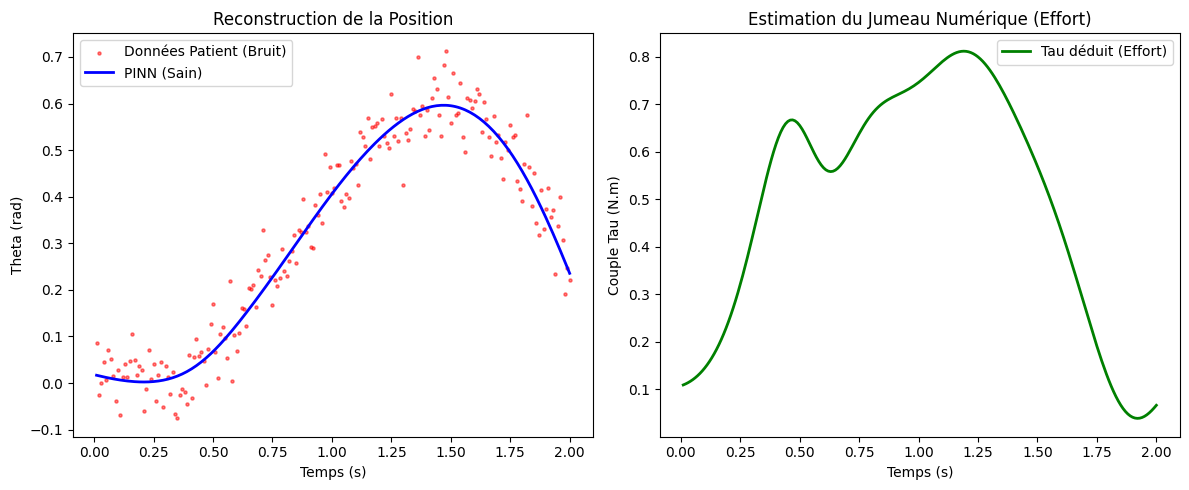

In [5]:
import torch
import torch.nn as nn

# ==========================================
# ÉTAPE 1 : Définition de l'Architecture
# Rôle : Créer le "cerveau" qui prédit la position
# ==========================================
class BioPINN(nn.Module):
    def __init__(self):
        super(BioPINN, self).__init__()
        # Input : Temps (t) -> 1 neurone
        # Hidden Layers : 3 couches de 64 neurones pour la fluidité
        # Output : Position (theta) -> 1 neurone
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(), # Tanh est crucial pour pouvoir dériver 2 fois
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1) 
        )

    def forward(self, t):
        # Rôle : Calculer la position theta pour un temps t donné
        return self.net(t)

# ==========================================
# ÉTAPE 2 : Paramètres Physiques et Modèle
# Rôle : Définir les constantes connues (I, b, k)
# ==========================================
I = 0.25  # Inertie
b = 0.15  # Frottement
k = 2.0   # Raideur
model = BioPINN()

# ==========================================
# ÉTAPE 3 : Calcul de la Loss (Physique + Data)
# Rôle : C'est ici que l'on déduit tau et qu'on optimise
# ==========================================
def compute_loss(t_train, theta_noisy, lambda_data=100, lambda_effort=0.5):
    # t_train doit permettre le calcul des gradients
    t_train.requires_grad = True
    
    # --- PRÉDICTION ---
    theta_pred = model(t_train)
    
    # --- ÉTAPE 4 : Calcul des dérivées (Autograd) ---
    # Rôle : Obtenir la vitesse et l'accélération sans calcul manuel
    dtheta = torch.autograd.grad(theta_pred, t_train, torch.ones_like(theta_pred), create_graph=True)[0]
    ddtheta = torch.autograd.grad(dtheta, t_train, torch.ones_like(dtheta), create_graph=True)[0]
    
    # --- ÉTAPE 5 : Déduction de TAU (La Physique) ---
    # Rôle : On utilise Newton pour extraire le couple moteur inconnu
    # Tau = I*ddtheta + b*dtheta + k*theta
    tau_deduit = I*ddtheta + b*dtheta + k*theta_pred
    
    # --- ÉTAPE 6 : Calcul des fonctions de coût (Losses) ---
    # 1. Fidélité aux données du patient
    loss_data = torch.mean((theta_pred - theta_noisy)**2)
    
    # 2. Critère Ergonomique (Minimisation de l'effort déduit)
    # C'est ici que l'on force le mouvement à être "sain" (effort minimum)
    loss_effort = torch.mean(tau_deduit**2)
    
    # --- ÉTAPE 7 : Pondération (Scaling) ---
    total_loss = lambda_data * loss_data + lambda_effort * loss_effort
    
    return total_loss, theta_pred, tau_deduit

# ==========================================
# ÉTAPE 8 : Choix de l'Optimiseur
# Rôle : Algorithme de descente de gradient (Adam)
# ==========================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# ==========================================
# ÉTAPE 9 : Boucle d'Entraînement (Training Loop)
# Rôle : Faire apprendre au réseau les poids optimaux
# ==========================================

# Conversion des données en tenseurs PyTorch (si ce n'est pas déjà fait)
t_tensor = torch.tensor(df['temps'].values, dtype=torch.float32).view(-1, 1)
theta_tensor = torch.tensor(df['theta'].values, dtype=torch.float32).view(-1, 1)

epochs = 3000
print("Lancement de l'entraînement...")

for epoch in range(epochs + 1):
    optimizer.zero_grad() # Réinitialiser les gradients
    
    # Appel de la fonction de perte définie précédemment
    loss, theta_p, tau_p = compute_loss(t_tensor, theta_tensor)
    
    loss.backward() # Rétropropagation (Calcul des gradients)
    optimizer.step() # Mise à jour des poids
    
    if epoch % 500 == 0:
        print(f"Époque {epoch} | Loss Totale : {loss.item():.6f}")

# ==========================================
# ÉTAPE 10 : Visualisation des Résultats
# Rôle : Afficher la trajectoire filtrée et l'effort calculé
# ==========================================
import matplotlib.pyplot as plt

# On passe en mode évaluation (pas de calcul de gradient pour le tracé)
model.eval()
with torch.no_grad():
    # Récupération des prédictions finales
    theta_final = model(t_tensor).numpy()
    # Pour tau, on doit le recalculer une dernière fois avec autograd hors boucle
    # (ou utiliser la dernière valeur calculée tau_p)
    tau_final = tau_p.detach().numpy()

plt.figure(figsize=(12, 5))

# Graphique 1 : Position theta
plt.subplot(1, 2, 1)
plt.scatter(t_tensor.detach().numpy(), theta_tensor.numpy(), color='red', s=5, alpha=0.5, label='Données Patient (Bruit)')
plt.plot(t_tensor.detach().numpy(), theta_final, color='blue', lw=2, label='PINN (Sain)')
plt.xlabel('Temps (s)')
plt.ylabel('Theta (rad)')
plt.title('Reconstruction de la Position')
plt.legend()

# Graphique 2 : Effort déduit Tau
plt.subplot(1, 2, 2)
plt.plot(t_tensor.detach().numpy(), tau_final, color='green', lw=2, label='Tau déduit (Effort)')
plt.xlabel('Temps (s)')
plt.ylabel('Couple Tau (N.m)')
plt.title('Estimation du Jumeau Numérique (Effort)')
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
# 1. Chargement des données
# On utilise header=None si le fichier CSV n'a pas encore de titres
df_sain = pd.read_csv('/kaggle/input/datasets/karimchibani/data-clean/theta_clean.csv') 

# 2. Définition des noms de colonnes (5 colonnes détectées dans ton extrait)
# D'après tes valeurs, l'ordre probable est : Temps, Theta, Vitesse, Accélération, Tau
nouveaux_noms = ['temps', 'theta_sain', 'vitesse', 'acceleration', 'tau_matlab']

# 3. Application des noms
# Vérification de sécurité pour éviter l'erreur si le nombre de colonnes diffère
if len(df_sain.columns) == len(nouveaux_noms):
    df_sain.columns = nouveaux_noms
    print("Succès : Les colonnes ont été renommées.")
else:
    print(f"Attention : Le fichier contient {len(df_sain.columns)} colonnes, "
          f"mais vous essayez d'en nommer {len(nouveaux_noms)}.")

# 4. Affichage pour vérification
print(df_sain.head())

Succès : Les colonnes ont été renommées.
   temps  theta_sain   vitesse  acceleration  tau_matlab
0   0.01    0.000000  0.000000      0.050263    0.012566
1   0.02    0.000003  0.000501      0.100194    0.025129
2   0.03    0.000013  0.001500      0.149741    0.037685
3   0.04    0.000035  0.002992      0.198855    0.050232
4   0.05    0.000075  0.004973      0.247487    0.062767


--- RÉSULTATS DE VALIDATION ---
Erreur Quadratique Moyenne (MSE) : 0.00015360
Coefficient de détermination (R²) : 0.9969


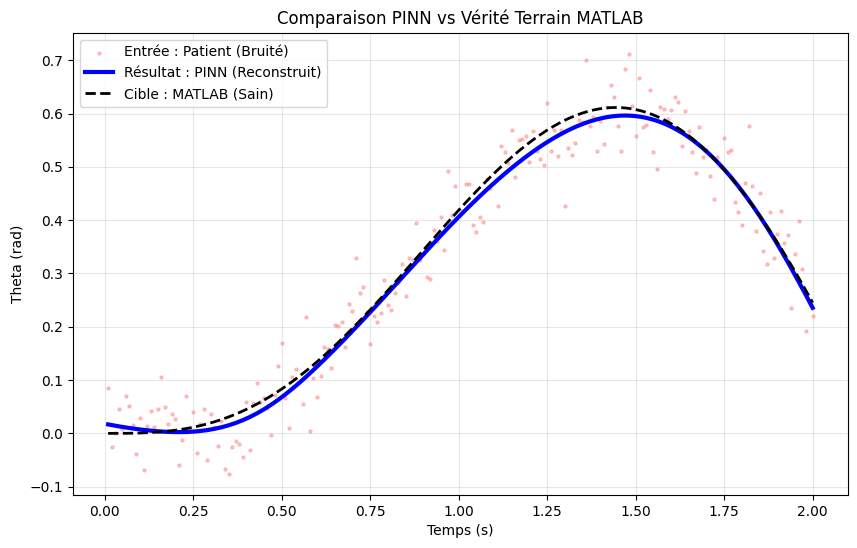

In [7]:
# ==========================================
# ÉTAPE 11 : Validation avec la Vérité Terrain (MATLAB)
# Rôle : Comparer le PINN avec les données saines réelles
# ==========================================

# 1. Charger et renommer les données saines (Exportées de MATLAB)
df_sain = pd.read_csv('/kaggle/input/datasets/karimchibani/data-clean/theta_clean.csv')

# On renomme les colonnes pour qu'elles correspondent à votre structure (5 colonnes)
# Cela assure que 'theta_sain' est bien identifié
df_sain.columns = ['temps', 'theta_sain', 'vitesse', 'acceleration', 'tau_matlab']

# Extraction de la position saine pour la comparaison
theta_sain_reel = df_sain['theta_sain'].values 

# 2. Calcul des métriques de performance
from sklearn.metrics import mean_squared_error, r2_score

# Calcul de l'erreur entre la prédiction PINN (theta_final) et la vérité MATLAB
mse_error = mean_squared_error(theta_sain_reel, theta_final)
r2 = r2_score(theta_sain_reel, theta_final)

print(f"--- RÉSULTATS DE VALIDATION ---")
print(f"Erreur Quadratique Moyenne (MSE) : {mse_error:.8f}")
print(f"Coefficient de détermination (R²) : {r2:.4f}")

# 3. Visualisation de la Comparaison Finale
plt.figure(figsize=(10, 6))

# Données bruitées du patient (Entrée du modèle)
plt.scatter(t_tensor.detach().numpy(), theta_tensor.numpy(), 
            color='red', s=5, alpha=0.2, label='Entrée : Patient (Bruité)')

# Résultat filtré par le PINN
plt.plot(t_tensor.detach().numpy(), theta_final, 
         'b-', lw=3, label='Résultat : PINN (Reconstruit)')

# Vérité terrain originale de MATLAB (La cible)
plt.plot(t_tensor.detach().numpy(), theta_sain_reel, 
         'k--', lw=2, label='Cible : MATLAB (Sain)')

plt.xlabel('Temps (s)')
plt.ylabel('Theta (rad)')
plt.title('Comparaison PINN vs Vérité Terrain MATLAB')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- PERFORMANCE DE L'ESTIMATION DE L'EFFORT ---
MSE sur Tau (Effort) : 0.00563772
Score R² sur Tau      : 0.9070


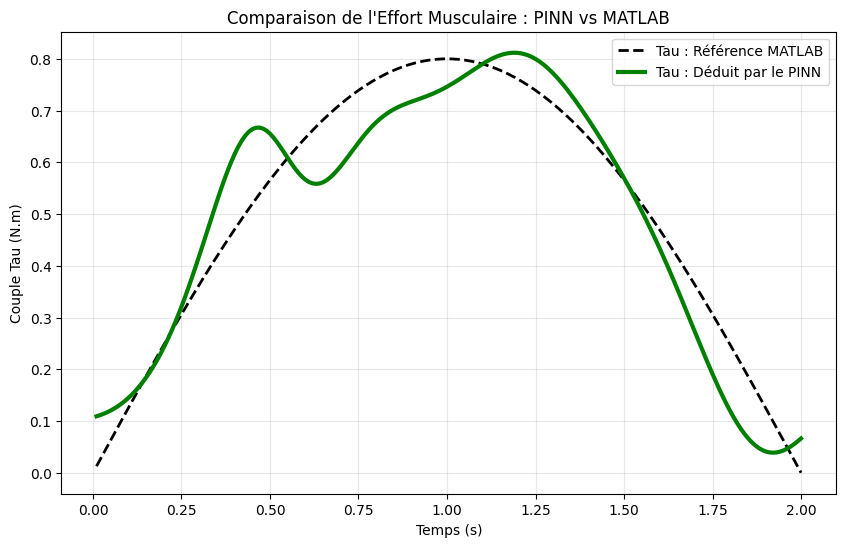

In [8]:
# ==========================================
# ÉTAPE 12 : Comparaison de l'Effort (Tau)
# Rôle : Vérifier si l'effort déduit par le PINN est fidèle à MATLAB
# ==========================================

# 1. Extraction du Tau de référence (MATLAB)
tau_reel = df_sain['tau_matlab'].values 

# 2. Calcul des métriques pour Tau
# On utilise tau_final qui a été calculé à l'étape précédente
mse_tau = mean_squared_error(tau_reel, tau_final)
r2_tau = r2_score(tau_reel, tau_final)

print(f"--- PERFORMANCE DE L'ESTIMATION DE L'EFFORT ---")
print(f"MSE sur Tau (Effort) : {mse_tau:.8f}")
print(f"Score R² sur Tau      : {r2_tau:.4f}")

# 3. Visualisation de la comparaison des courbes de Tau
plt.figure(figsize=(10, 6))

# Courbe MATLAB (La référence)
plt.plot(t_tensor.detach().numpy(), tau_reel, 'k--', lw=2, label='Tau : Référence MATLAB')

# Courbe PINN (L'estimation)
plt.plot(t_tensor.detach().numpy(), tau_final, 'g-', lw=3, label='Tau : Déduit par le PINN')

plt.xlabel('Temps (s)')
plt.ylabel('Couple Tau (N.m)')
plt.title('Comparaison de l\'Effort Musculaire : PINN vs MATLAB')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

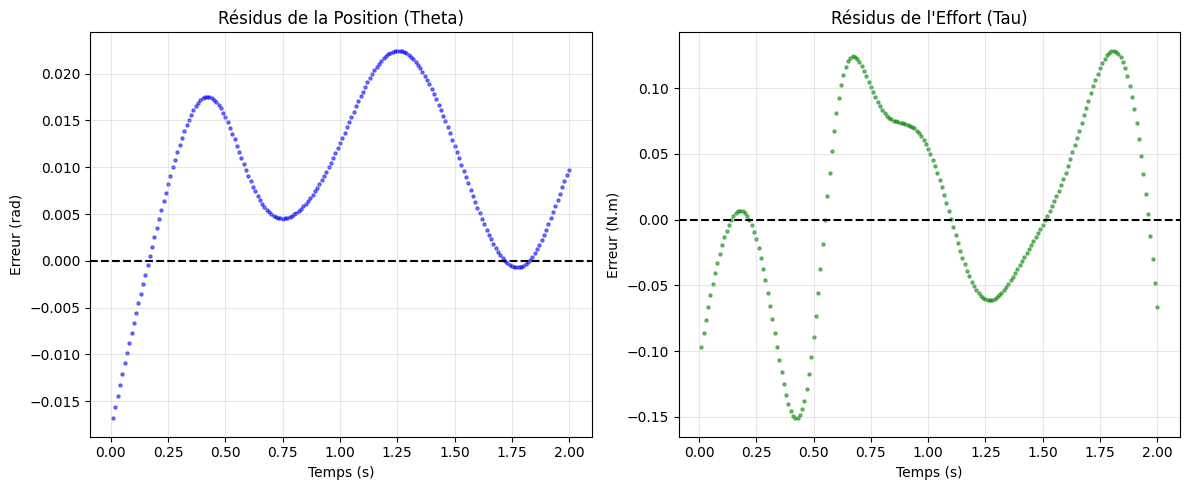

--- ANALYSE STATISTIQUE DES RÉSIDUS ---
Moyenne des résidus (Theta) : 0.00904297
Moyenne des résidus (Tau)   : 0.01185228


In [9]:
# ==========================================
# ÉTAPE 13 : Analyse des Résidus
# Rôle : Vérifier la qualité statistique des erreurs
# ==========================================

# 1. Calcul des erreurs (Résidus)
residu_theta = theta_sain_reel - theta_final.flatten()
residu_tau = tau_reel - tau_final.flatten()

plt.figure(figsize=(12, 5))

# --- Graphique 1 : Résidus de la Position ---
plt.subplot(1, 2, 1)
plt.scatter(t_tensor.detach().numpy(), residu_theta, color='blue', s=5, alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--') # Ligne zéro
plt.xlabel('Temps (s)')
plt.ylabel('Erreur (rad)')
plt.title('Résidus de la Position (Theta)')
plt.grid(True, alpha=0.3)

# --- Graphique 2 : Résidus de l'Effort ---
plt.subplot(1, 2, 2)
plt.scatter(t_tensor.detach().numpy(), residu_tau, color='green', s=5, alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--') # Ligne zéro
plt.xlabel('Temps (s)')
plt.ylabel('Erreur (N.m)')
plt.title('Résidus de l\'Effort (Tau)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Vérification statistique simple
print(f"--- ANALYSE STATISTIQUE DES RÉSIDUS ---")
print(f"Moyenne des résidus (Theta) : {np.mean(residu_theta):.8f}")
print(f"Moyenne des résidus (Tau)   : {np.mean(residu_tau):.8f}")